Best Source Angle: (-15.0, -11.666666666666666)
Best Fidelity Index: 0.0413


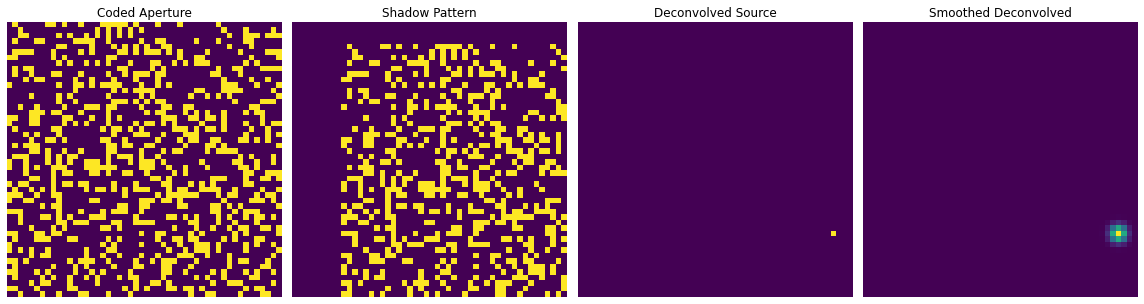

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, gaussian_filter

# 1. Generate a random coded aperture mask
def generate_mask(size, density):
    np.random.seed(0)  # Seed for reproducibility
    mask = np.random.choice([0, 1], size=size, p=[1 - density, density])  # Binary mask
    return mask

# 2. Compute the shadow for a given angle and PSF
def compute_shadow(mask, source_angle, height, detector_size, pixel_size):
    theta_x, theta_y = source_angle
    delta_x = int(round(height * np.tan(theta_x) / pixel_size))
    delta_y = int(round(height * np.tan(theta_y) / pixel_size))

    det_h, det_w = detector_size
    mask_h, mask_w = mask.shape
    mask_center = (mask_h // 2, mask_w // 2)
    det_center = (det_h // 2, det_w // 2)

    shadow = np.zeros((det_h, det_w))

    shadow_x_min = max(det_center[1] - mask_center[1] + delta_x, 0)
    shadow_x_max = min(det_center[1] + mask_center[1] + delta_x, det_w)
    shadow_y_min = max(det_center[0] - mask_center[0] + delta_y, 0)
    shadow_y_max = min(det_center[0] + mask_center[0] + delta_y, det_h)

    mask_x_min = max(mask_center[1] - det_center[1] - delta_x, 0)
    mask_x_max = mask_x_min + (shadow_x_max - shadow_x_min)
    mask_y_min = max(mask_center[0] - det_center[0] - delta_y, 0)
    mask_y_max = mask_y_min + (shadow_y_max - shadow_y_min)

    if shadow_x_max > shadow_x_min and shadow_y_max > shadow_y_min:
        shadow[shadow_y_min:shadow_y_max, shadow_x_min:shadow_x_max] = mask[
            mask_y_min:mask_y_max, mask_x_min:mask_x_max
        ]

    return shadow

# 3. Richardson-Lucy Deconvolution with PSF
def richardson_lucy_deconvolution_2d(observed, psf, epsilon=1e-5, max_iter=50):
    F = np.full_like(observed, np.mean(observed))
    for _ in range(max_iter):
        G = convolve(F, psf, mode='constant', cval=0.0)
        C = observed / (G + epsilon)
        correction = convolve(C, np.flip(np.flip(psf, axis=0), axis=1), mode='constant', cval=0.0)
        F = F * correction
    return F

# 4. Compute Fidelity Index
def fidelity_index(original, reconstructed):
    numerator = np.sum(original * reconstructed)
    denominator = np.sqrt(np.sum(original**2) * np.sum(reconstructed**2))
    return numerator / (denominator + 1e-10)

# 5. Chi-Squared Metric
def chi_squared(original, reconstructed, noise_variance):
    diff = original - reconstructed
    return np.sum((diff**2) / noise_variance)

# 6. Grid Search for Best Source Angle
def grid_search(mask, shadow, height, detector_size, pixel_size, angle_range, noise_variance, epsilon, max_iter):
    best_fidelity = -1
    best_angle = None
    best_reconstruction = None

    for theta_x in angle_range:
        for theta_y in angle_range:
            psf = compute_shadow(mask, (np.radians(theta_x), np.radians(theta_y)), height, detector_size, pixel_size)
            reconstruction = richardson_lucy_deconvolution_2d(shadow, psf, epsilon, max_iter)
            fidelity = fidelity_index(shadow, reconstruction)
            if fidelity > best_fidelity:
                best_fidelity = fidelity
                best_angle = (theta_x, theta_y)
                best_reconstruction = reconstruction

    return best_angle, best_fidelity, best_reconstruction

# Visualization Function
def visualize(mask, shadow, deconvolved, deconvolved_smoothed):
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    titles = ['Coded Aperture', 'Shadow Pattern', 'Deconvolved Source', 'Smoothed Deconvolved']
    images = [mask, shadow, deconvolved, deconvolved_smoothed]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='viridis')
        ax.axis('off')
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

# Parameters
mask_size = (50, 50)
density = 0.3
detector_size = (50, 50)
height = 50.0
pixel_size = 1.0
angle_range = np.linspace(-15, 15, 10)  # Search angles in degrees
epsilon = 1e-5
max_iter = 50
noise_variance = 0.01

# Run
mask = generate_mask(mask_size, density)
source_angle = (np.radians(10), np.radians(5))  # True angles
shadow = compute_shadow(mask, source_angle, height, detector_size, pixel_size)
best_angle, best_fidelity, best_reconstruction = grid_search(
    mask, shadow, height, detector_size, pixel_size, angle_range, noise_variance, epsilon, max_iter
)
deconvolved_source_smoothed = gaussian_filter(best_reconstruction, sigma=1)

# Results
print(f"Best Source Angle: {best_angle}")
print(f"Best Fidelity Index: {best_fidelity:.4f}")
visualize(mask, shadow, best_reconstruction, deconvolved_source_smoothed)

In [23]:
# True source angle (used only for validation)
source_angle = (np.radians(10), np.radians(5))  # True angles in radians

# Run grid search
best_angle, best_fidelity, best_reconstruction = grid_search(
    mask, shadow, height, detector_size, pixel_size, angle_range, noise_variance, epsilon, max_iter
)

# Convert best angle to radians
best_angle_radians = (np.radians(best_angle[0]), np.radians(best_angle[1]))

# Compute angular error
angular_error = (
    abs(source_angle[0] - best_angle_radians[0]),
    abs(source_angle[1] - best_angle_radians[1])
)
total_error = np.sqrt(angular_error[0]**2 + angular_error[1]**2)

# Display results
print(f"True Source Angle: ({np.degrees(source_angle[0]):.2f}, {np.degrees(source_angle[1]):.2f}) degrees")
print(f"Estimated Source Angle: ({best_angle[0]:.2f}, {best_angle[1]:.2f}) degrees")
print(f"Angular Error: ({np.degrees(angular_error[0]):.2f}, {np.degrees(angular_error[1]):.2f}) degrees")
print(f"Total Angular Error (Euclidean): {np.degrees(total_error):.2f} degrees")

True Source Angle: (10.00, 5.00) degrees
Estimated Source Angle: (-15.00, -11.67) degrees
Angular Error: (25.00, 16.67) degrees
Total Angular Error (Euclidean): 30.05 degrees


Best Source Angle: (1.6666666666666679, 1.6666666666666679)
Best Fidelity Index: 0.7254


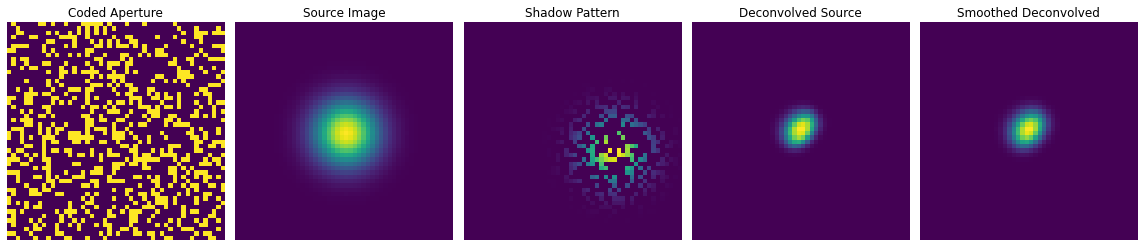

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, gaussian_filter, rotate

# 1. Generate a random coded aperture mask
def generate_mask(size, density):
    np.random.seed(0)  # Seed for reproducibility
    mask = np.random.choice([0, 1], size=size, p=[1 - density, density])  # Binary mask
    return mask

# 2. Generate a star-like source (Gaussian intensity distribution)
def generate_star_source(size, center, sigma):
    """Generate a star-like intensity distribution (Gaussian source)."""
    x = np.linspace(0, size[1] - 1, size[1])
    y = np.linspace(0, size[0] - 1, size[0])
    X, Y = np.meshgrid(x, y)
    gauss = np.exp(-((X - center[1])**2 + (Y - center[0])**2) / (2 * sigma**2))
    return gauss / gauss.max()  # Normalize to [0, 1]

# 3. Compute the shadow for a given angle and PSF
def compute_shadow(mask, source_image, source_angle, height, detector_size, pixel_size):
    """
    Computes the shadow pattern cast by the source through the coded aperture mask without rotating the source image.
    """
    theta_x, theta_y = source_angle

    # Initialize the shadow pattern
    shadow = np.zeros(detector_size)

    # Dimensions and centers
    source_h, source_w = source_image.shape
    det_h, det_w = detector_size
    det_center = (det_h // 2, det_w // 2)  # Detector center
    source_center = (source_h // 2, source_w // 2)  # Source center

    # Compute shadow displacement based on angles
    delta_x = int(round(height * np.tan(theta_x) / pixel_size))
    delta_y = int(round(height * np.tan(theta_y) / pixel_size))

    # Map the stationary source onto the detector, accounting for displacement
    shadow_x_min = max(det_center[1] - source_center[1] + delta_x, 0)
    shadow_x_max = min(det_center[1] + source_center[1] + delta_x, det_w)
    shadow_y_min = max(det_center[0] - source_center[0] + delta_y, 0)
    shadow_y_max = min(det_center[0] + source_center[0] + delta_y, det_h)

    source_x_min = max(source_center[1] - det_center[1] - delta_x, 0)
    source_x_max = source_x_min + (shadow_x_max - shadow_x_min)
    source_y_min = max(source_center[0] - det_center[0] - delta_y, 0)
    source_y_max = source_y_min + (shadow_y_max - shadow_y_min)

    # Place the stationary source within the shadow area
    if shadow_x_max > shadow_x_min and shadow_y_max > shadow_y_min:
        shadow[shadow_y_min:shadow_y_max, shadow_x_min:shadow_x_max] = source_image[
            source_y_min:source_y_max, source_x_min:source_x_max
        ]

    # Multiply the shadow by the mask to simulate the coded aperture effect
    shadow *= mask

    return shadow

# 4. Richardson-Lucy Deconvolution
def richardson_lucy_deconvolution_2d(observed, psf, epsilon=1e-5, max_iter=50):
    F = np.full_like(observed, np.mean(observed))
    for _ in range(max_iter):
        G = convolve(F, psf, mode='constant', cval=0.0)
        C = observed / (G + epsilon)
        correction = convolve(C, np.flip(np.flip(psf, axis=0), axis=1), mode='constant', cval=0.0)
        F = F * correction
    return F

# 5. Compute Fidelity Index
def fidelity_index(original, reconstructed):
    numerator = np.sum(original * reconstructed)
    denominator = np.sqrt(np.sum(original**2) * np.sum(reconstructed**2))
    return numerator / (denominator + 1e-10)

# 6. Grid Search for Best Source Angle
def grid_search(mask, source_image, height, detector_size, pixel_size, angle_range, noise_variance, epsilon, max_iter):
    best_fidelity = -1
    best_angle = None
    best_reconstruction = None

    for theta_x in angle_range:
        for theta_y in angle_range:
            psf = compute_shadow(mask, source_image, (np.radians(theta_x), np.radians(theta_y)), height, detector_size, pixel_size)
            reconstruction = richardson_lucy_deconvolution_2d(source_image, psf, epsilon, max_iter)
            fidelity = fidelity_index(source_image, reconstruction)
            if fidelity > best_fidelity:
                best_fidelity = fidelity
                best_angle = (theta_x, theta_y)
                best_reconstruction = reconstruction

    return best_angle, best_fidelity, best_reconstruction

# 7. Visualization Function
def visualize(mask, source_image, shadow, deconvolved, deconvolved_smoothed):
    fig, axes = plt.subplots(1, 5, figsize=(16, 5))
    titles = ['Coded Aperture', 'Source Image', 'Shadow Pattern', 'Deconvolved Source', 'Smoothed Deconvolved']
    images = [mask, source_image, shadow, deconvolved, deconvolved_smoothed]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='viridis')
        ax.axis('off')
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

# Parameters
mask_size = (50, 50)
density = 0.3
detector_size = (50, 50)
height = 50.0
pixel_size = 1.0
angle_range = np.linspace(-15, 15, 10)  # Search angles in degrees
epsilon = 1e-5
max_iter = 50
noise_variance = 0.01

# Run
mask = generate_mask(mask_size, density)
source_image = generate_star_source(size=(50, 50), center=(25, 25), sigma=5.0)  # Star-like source
shadow = compute_shadow(mask, source_image, (np.radians(10), np.radians(5)), height, detector_size, pixel_size)
best_angle, best_fidelity, best_reconstruction = grid_search(
    mask, source_image, height, detector_size, pixel_size, angle_range, noise_variance, epsilon, max_iter
)
deconvolved_source_smoothed = gaussian_filter(best_reconstruction, sigma=1)

# Results
print(f"Best Source Angle: {best_angle}")
print(f"Best Fidelity Index: {best_fidelity:.4f}")
visualize(mask, source_image, shadow, best_reconstruction, deconvolved_source_smoothed)

Best Source Angle: (-1.666666666666666, -1.666666666666666)
Best Fidelity Index: 0.8834


NameError: name 'generate_star_source_with_displacement' is not defined

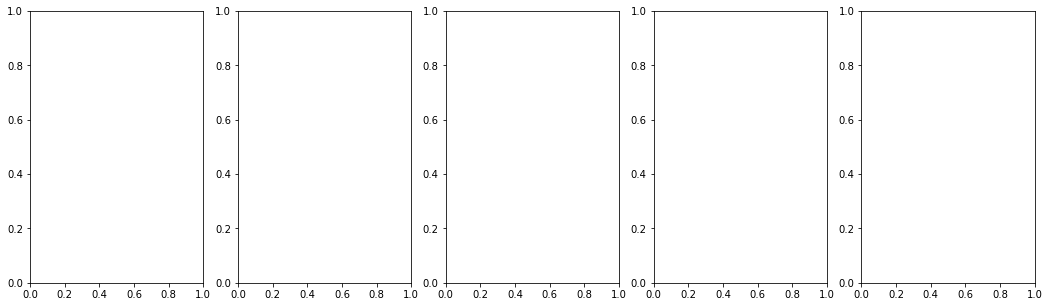

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, gaussian_filter

# 1. Generate a random coded aperture mask
def generate_mask(size, density):
    np.random.seed(0)  # Seed for reproducibility
    mask = np.random.choice([0, 1], size=size, p=[1 - density, density])  # Binary mask
    return mask

# 2. Generate a star-like source (Gaussian intensity distribution)
def generate_star_source(size, center, sigma):
    """Generate a star-like intensity distribution (Gaussian source)."""
    x = np.linspace(0, size[1] - 1, size[1])
    y = np.linspace(0, size[0] - 1, size[0])
    X, Y = np.meshgrid(x, y)
    gauss = np.exp(-((X - center[1])**2 + (Y - center[0])**2) / (2 * sigma**2))
    return gauss / gauss.max()  # Normalize to [0, 1]

# 3. Compute the realistic shadow pattern with angular displacement
def compute_realistic_shadow(mask, source_angle, height_mask_to_detector, height_source_to_mask, detector_size, pixel_size):
    theta_x, theta_y = source_angle

    # Calculate displacement on the mask
    delta_x_on_mask = height_source_to_mask * np.tan(theta_x)
    delta_y_on_mask = height_source_to_mask * np.tan(theta_y)

    # Calculate displacement on the detector (propagated further)
    delta_x_on_detector = (height_mask_to_detector / height_source_to_mask) * delta_x_on_mask
    delta_y_on_detector = (height_mask_to_detector / height_source_to_mask) * delta_y_on_mask

    # Convert displacement to pixels
    delta_x_pixels = int(round(delta_x_on_detector / pixel_size))
    delta_y_pixels = int(round(delta_y_on_detector / pixel_size))

    # Project mask onto the detector
    projected_mask = np.zeros(detector_size)
    mask_h, mask_w = mask.shape
    det_h, det_w = detector_size

    # Centering calculations
    mask_center = (mask_h // 2, mask_w // 2)
    detector_center = (det_h // 2, det_w // 2)

    # Calculate ranges for projection
    # Detector region adjusted for opposite-direction displacement
    x_min = max(detector_center[1] - mask_center[1] - delta_x_pixels, 0)
    x_max = min(detector_center[1] + mask_center[1] - delta_x_pixels, det_w)
    y_min = max(detector_center[0] - mask_center[0] - delta_y_pixels, 0)
    y_max = min(detector_center[0] + mask_center[0] - delta_y_pixels, det_h)

    # Mask region aligned with inverted displacement
    mask_x_min = max(mask_center[1] - detector_center[1] + delta_x_pixels, 0)
    mask_x_max = mask_x_min + (x_max - x_min)
    mask_y_min = max(mask_center[0] - detector_center[0] + delta_y_pixels, 0)
    mask_y_max = mask_y_min + (y_max - y_min)

    # Place the projected mask onto the detector
    if x_max > x_min and y_max > y_min:
        projected_mask[y_min:y_max, x_min:x_max] = mask[mask_y_min:mask_y_max, mask_x_min:mask_x_max]

    return projected_mask, (delta_x_pixels, delta_y_pixels)

# 4. Richardson-Lucy Deconvolution with automatic displacement compensation
def richardson_lucy_auto_displacement(observed, psf, epsilon=1e-5, max_iter=50):
    F = np.full_like(observed, np.mean(observed))  # Start with mean guess
    for _ in range(max_iter):
        G = convolve(F, psf, mode='constant', cval=0.0)
        C = observed / (G + epsilon)
        correction = convolve(C, np.flip(np.flip(psf, axis=0), axis=1), mode='constant', cval=0.0)
        F = F * correction
    return F

# 5. Compute Fidelity Index
def fidelity_index(original, reconstructed):
    numerator = np.sum(original * reconstructed)
    denominator = np.sqrt(np.sum(original**2) * np.sum(reconstructed**2))
    return numerator / (denominator + 1e-10)

# 6. Grid Search for Best Source Angle
def grid_search(mask, source_image, height_source_to_mask, height_mask_to_detector, detector_size, pixel_size, angle_range, noise_variance, epsilon, max_iter):
    best_fidelity = -1
    best_angle = None
    best_reconstruction = None

    for theta_x in angle_range:
        for theta_y in angle_range:
            psf, displacement = compute_realistic_shadow(
                mask, 
                source_angle=(np.radians(theta_x), np.radians(theta_y)), 
                height_mask_to_detector=height_mask_to_detector, 
                height_source_to_mask=height_source_to_mask, 
                detector_size=detector_size, 
                pixel_size=pixel_size
            )
            reconstruction = richardson_lucy_auto_displacement(source_image, psf, epsilon, max_iter)
            fidelity = fidelity_index(source_image, reconstruction)
            if fidelity > best_fidelity:
                best_fidelity = fidelity
                best_angle = (theta_x, theta_y)
                best_reconstruction = reconstruction

    return best_angle, best_fidelity, best_reconstruction

# 7. Visualization Function
def visualize_results(mask, source_image, shadow, deconvolved, deconvolved_smoothed, displacement):
    fig, axes = plt.subplots(1, 5, figsize=(18, 5))
    titles = ['Coded Aperture', 'Source Image', 'Shadow Pattern', 'Deconvolved Source', 'Smoothed Deconvolved']

    displaced_source_image = generate_star_source_with_displacement(mask.shape, (25, 25), 5.0, displacement)
    displaced_deconvolved = np.roll(deconvolved, displacement, axis=(0, 1))

    images = [mask, displaced_source_image, shadow, displaced_deconvolved, deconvolved_smoothed]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='viridis')
        ax.axis('off')
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

# Parameters
mask_size = (50, 50)
density = 0.3
detector_size = (50, 50)
height_source_to_mask = 50.0
height_mask_to_detector = 20.0
pixel_size = 1.0
angle_range = np.linspace(-15, 15, 10)  # Search angles in degrees
epsilon = 1e-5
max_iter = 50
noise_variance = 0.01

# Run
mask = generate_mask(mask_size, density)
source_image = generate_star_source(size=(50, 50), center=(25, 25), sigma=5.0)  # Star-like source
shadow, displacement = compute_realistic_shadow(
    mask, 
    source_angle=(np.radians(20), np.radians(5)), 
    height_mask_to_detector=height_mask_to_detector,
    height_source_to_mask=height_source_to_mask,
    detector_size=detector_size, 
    pixel_size=pixel_size
)
best_angle, best_fidelity, best_reconstruction = grid_search(
    mask, source_image, height_source_to_mask, height_mask_to_detector, detector_size, pixel_size, angle_range, noise_variance, epsilon, max_iter
)
deconvolved_source_smoothed = gaussian_filter(best_reconstruction, sigma=1)

# Results
print(f"Best Source Angle: {best_angle}")
print(f"Best Fidelity Index: {best_fidelity:.4f}")
visualize_results(mask, source_image, shadow, best_reconstruction, deconvolved_source_smoothed, displacement)

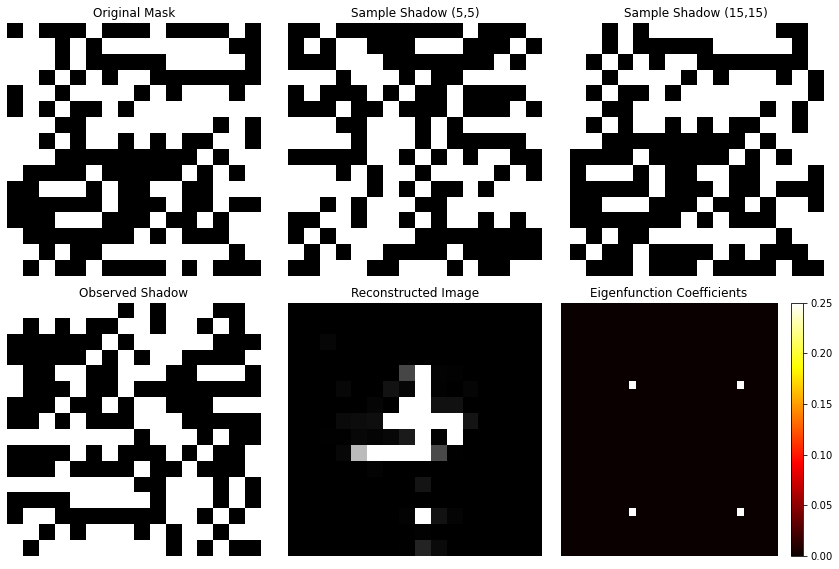

Reconstruction completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy

# Parameters
mask_size = (16, 16)
image_size = (32, 32)
num_positions = 32

# Generate random binary mask
np.random.seed(42)
mask = np.random.choice([0, 1], size=mask_size)

# Generate shadow library for different source positions
shadow_lib = np.zeros((num_positions, num_positions, *mask_size))
for i in range(num_positions):
    for j in range(num_positions):
        shifted_mask = np.roll(np.roll(mask, i, axis=0), j, axis=1)
        shadow_lib[i, j] = shifted_mask

# Create observed shadow (Example: source at (10,10))
source_pos = (10, 10)
observed_shadow = shadow_lib[source_pos]

# Apply Richardson-Lucy deconvolution
num_iterations = 30
reconstructed_image = richardson_lucy(observed_shadow, mask, num_iterations)

# Eigenfunction-based restoration
coefficients = np.linalg.lstsq(shadow_lib.reshape(num_positions*num_positions, -1).T, observed_shadow.flatten(), rcond=None)[0]

# Visualization
plt.figure(figsize=(12, 8))

# Original mask
plt.subplot(2, 3, 1)
plt.imshow(mask, cmap='gray')
plt.title("Original Mask")
plt.axis("off")

# Sample shadow patterns
plt.subplot(2, 3, 2)
plt.imshow(shadow_lib[5, 5], cmap='gray')
plt.title("Sample Shadow (5,5)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(shadow_lib[15, 15], cmap='gray')
plt.title("Sample Shadow (15,15)")
plt.axis("off")

# Observed shadow
plt.subplot(2, 3, 4)
plt.imshow(observed_shadow, cmap='gray')
plt.title("Observed Shadow")
plt.axis("off")

# Restored image
plt.subplot(2, 3, 5)
plt.imshow(reconstructed_image, cmap='gray')
plt.title("Reconstructed Image")
plt.axis("off")

# Heatmap of eigenfunction coefficients
plt.subplot(2, 3, 6)
plt.imshow(coefficients.reshape(num_positions, num_positions), cmap='hot', aspect='auto')
plt.colorbar()
plt.title("Eigenfunction Coefficients")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")

In [ ]:
import numpy as np
import scipy.ndimage as ndimage
import scipy.signal as signal
from skimage.restoration import richardson_lucy

# Define parameters
MASK_SIZE = 16  # Each shadow pattern is 16x16
LIBRARY_SIZE = 32  # Shadow library is 32x32
IMAGE_SIZE = MASK_SIZE * LIBRARY_SIZE  # 512x512 overall image size
H = 1.0  # Distance parameter for displacement
THETA_STEP = np.arctan(1.0 / H)  # Angle shift per pixel

# Generate a random binary mask
def generate_mask(size):
    return np.random.choice([0, 1], size=(size, size))

# Generate shadow pattern for given angles
def generate_shadow(mask, theta_x, theta_y):
    shift_x = int(H * np.tan(theta_x))
    shift_y = int(H * np.tan(theta_y))
    return ndimage.shift(mask, shift=(shift_x, shift_y), mode='constant', cval=0)

# Create shadow library
def create_shadow_library(mask):
    library = np.zeros((LIBRARY_SIZE, LIBRARY_SIZE, MASK_SIZE, MASK_SIZE))
    for i in range(LIBRARY_SIZE):
        for j in range(LIBRARY_SIZE):
            theta_x, theta_y = i * THETA_STEP, j * THETA_STEP
            library[i, j] = generate_shadow(mask, theta_x, theta_y)
    return library

# Richardson-Lucy deconvolution with stopping criterion
def rl_deconvolution(observed, psf, iterations=50, tol=1e-3):
    previous = np.copy(observed)
    for i in range(iterations):
        deconvolved = richardson_lucy(observed, psf, iterations=1)
        if np.allclose(deconvolved, previous, atol=tol):
            break
        previous = deconvolved
    return deconvolved

# Maximum Entropy Restoration (placeholder for now)
def max_entropy_restoration(image):
    return image / np.sum(image)  # Simple normalization for now

# Eigenfunction-based restoration (shadow decomposition)
def eigen_restore(shadow_lib, observed_shadow):
    num_basis = LIBRARY_SIZE * LIBRARY_SIZE  # 32 * 32 = 1024
    num_pixels = MASK_SIZE * MASK_SIZE  # 16 * 16 = 256

    # Reshape shadow_lib into (num_basis, num_pixels)
    shadow_basis = shadow_lib.reshape(num_basis, num_pixels).T  # Shape (256, 1024)

    # Flatten observed_shadow into a 256-element vector
    observed_flat = observed_shadow.flatten()  # Shape (256,)

    # Solve least squares Ax = b
    coeffs = np.linalg.lstsq(shadow_basis, observed_flat, rcond=None)[0]
    return coeffs

# Image reconstruction pipeline
def reconstruct_image():
    mask = generate_mask(MASK_SIZE)
    shadow_library = create_shadow_library(mask)
    
    # Simulate an observed image with arbitrary intensity distribution
    observed_image = np.random.rand(IMAGE_SIZE, IMAGE_SIZE)
    observed_shadow = np.random.rand(MASK_SIZE, MASK_SIZE)  # Simulated observed shadow
    
    # Apply Richardson-Lucy deconvolution
    restored_image = rl_deconvolution(observed_image, mask)
    
    # Apply Maximum Entropy restoration
    final_image = max_entropy_restoration(restored_image)
    
    # Eigenfunction restoration
    coefficients = eigen_restore(shadow_library, observed_shadow)
    
    return final_image, shadow_library, coefficients

# Run the reconstruction
reconstructed_image, shadow_lib, coeffs = reconstruct_image()

# Debug outputs
print("Reconstruction completed.")
print("Eigenfunction coefficients:", coeffs)

Reconstruction completed.
Eigenfunction coefficients: [1.08871833e-03 1.08871833e-03 6.93889390e-18 ... 1.74413364e-03
 0.00000000e+00 1.43232587e-03]


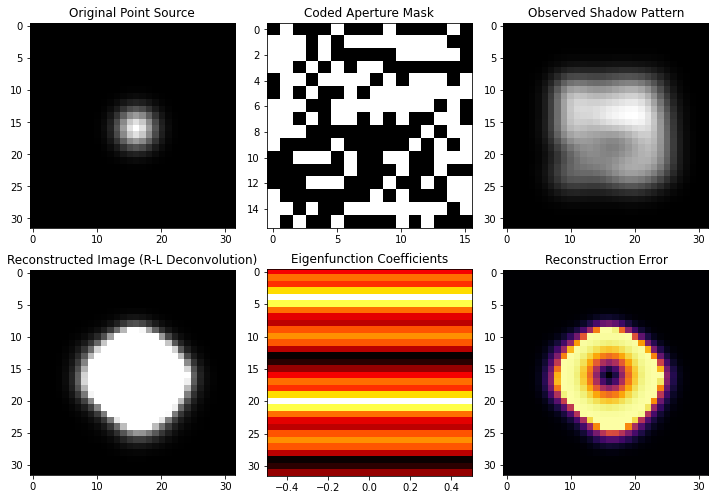

Reconstruction completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy
from skimage.transform import resize

# Step 1: Define Original Point Source (Gaussian Blob)
def gaussian_2d(shape, center, sigma=2):
    """Generate a 2D Gaussian distribution as a point source."""
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    return np.exp(-((x - center[0])**2 + (y - center[1])**2) / (2 * sigma**2))

original_source = gaussian_2d((32, 32), center=(16, 16), sigma=2)

# Step 2: Generate Random Mask (Binary Coded Aperture)
np.random.seed(42)
mask = np.random.choice([0, 1], size=(16, 16))

# Step 3: Create Shadow Pattern (Observed Image)
shadow_pattern = convolve2d(original_source, mask, mode='same')

# Step 4: Apply Richardson-Lucy Deconvolution
reconstructed_image = richardson_lucy(shadow_pattern, mask, iterations=10)

# Step 5: Generate Correctly Sized Shadow Library
shadow_lib = np.zeros((32, 32, 32))  # 32 shadow patterns, each 32×32

for shift in range(32):
    shifted_mask = np.roll(mask, shift, axis=0)  # Shift along rows
    shifted_mask = np.roll(shifted_mask, shift, axis=1)  # Shift along columns
    upscaled_mask = resize(shifted_mask, (32, 32), mode='reflect', anti_aliasing=True)
    shadow_lib[shift] = upscaled_mask

# Step 6: Eigenfunction-Based Restoration (Fixed Dimension Matching)
def eigen_restore(shadow_lib, observed_shadow):
    """Find the best coefficient match for the shadow decomposition."""
    shadow_lib_reshaped = shadow_lib.reshape(shadow_lib.shape[0], -1)  # Flatten each shadow into a row
    observed_shadow_flat = observed_shadow.flatten()  # Flatten observed shadow into a vector

    if shadow_lib_reshaped.shape[1] != observed_shadow_flat.shape[0]:
        raise ValueError(f"Dimension mismatch: Shadow lib {shadow_lib_reshaped.shape} vs Observed {observed_shadow_flat.shape}")

    coeffs = np.linalg.lstsq(shadow_lib_reshaped.T, observed_shadow_flat, rcond=None)[0]
    return coeffs

# Compute Eigenfunction Coefficients
coefficients = eigen_restore(shadow_lib, shadow_pattern)

# Step 7: Visualization
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

# Original Point Source
axes[0, 0].imshow(original_source, cmap='gray')
axes[0, 0].set_title("Original Point Source")

# Random Coded Aperture Mask
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Coded Aperture Mask")

# Shadow Pattern (Observed Image)
axes[0, 2].imshow(shadow_pattern, cmap='gray')
axes[0, 2].set_title("Observed Shadow Pattern")

# Richardson-Lucy Reconstructed Image
axes[1, 0].imshow(reconstructed_image, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (R-L Deconvolution)")

# Eigenfunction Coefficients Heatmap
axes[1, 1].imshow(coefficients.reshape(32, 1), cmap='hot', aspect='auto')
axes[1, 1].set_title("Eigenfunction Coefficients")

# Difference between Original and Reconstructed
error = np.abs(original_source - reconstructed_image)
axes[1, 2].imshow(error, cmap='inferno')
axes[1, 2].set_title("Reconstruction Error")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")


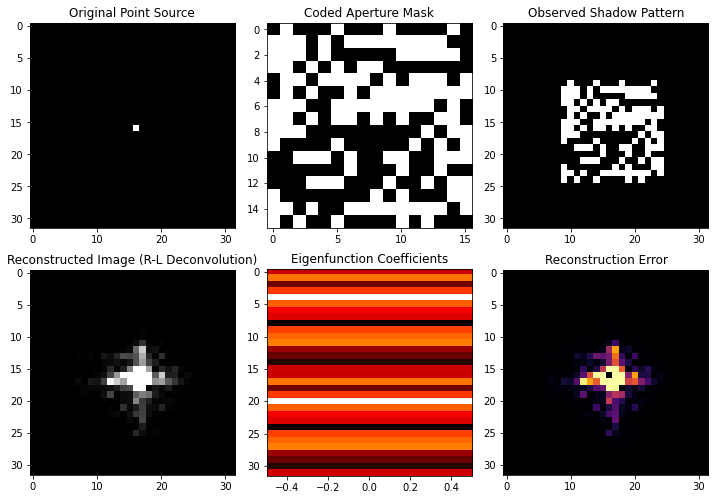

Reconstruction completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy
from skimage.transform import resize

# Step 1: Define Original Point Source (Gaussian Blob)
# Step 1: Define a True Point Source
def point_source(shape, center):
    """Create a true point source (single bright pixel)."""
    source = np.zeros(shape)
    source[center] = 1  # Single bright pixel
    return source

original_source = point_source((32, 32), center=(16, 16))


# Step 2: Generate Random Mask (Binary Coded Aperture)
np.random.seed(42)
mask = np.random.choice([0, 1], size=(16, 16))

# Step 3: Create Shadow Pattern (Observed Image)
shadow_pattern = convolve2d(original_source, mask, mode='same')

# Step 4: Apply Richardson-Lucy Deconvolution
reconstructed_image = richardson_lucy(shadow_pattern, mask, iterations=10)

# Step 5: Generate Correctly Sized Shadow Library
shadow_lib = np.zeros((32, 32, 32))  # 32 shadow patterns, each 32×32

for shift in range(32):
    shifted_mask = np.roll(mask, shift, axis=0)  # Shift along rows
    shifted_mask = np.roll(shifted_mask, shift, axis=1)  # Shift along columns
    upscaled_mask = resize(shifted_mask, (32, 32), mode='reflect', anti_aliasing=True)
    shadow_lib[shift] = upscaled_mask

# Step 6: Eigenfunction-Based Restoration (Fixed Dimension Matching)
def eigen_restore(shadow_lib, observed_shadow):
    """Find the best coefficient match for the shadow decomposition."""
    shadow_lib_reshaped = shadow_lib.reshape(shadow_lib.shape[0], -1)  # Flatten each shadow into a row
    observed_shadow_flat = observed_shadow.flatten()  # Flatten observed shadow into a vector

    if shadow_lib_reshaped.shape[1] != observed_shadow_flat.shape[0]:
        raise ValueError(f"Dimension mismatch: Shadow lib {shadow_lib_reshaped.shape} vs Observed {observed_shadow_flat.shape}")

    coeffs = np.linalg.lstsq(shadow_lib_reshaped.T, observed_shadow_flat, rcond=None)[0]
    return coeffs

# Compute Eigenfunction Coefficients
coefficients = eigen_restore(shadow_lib, shadow_pattern)

# Step 7: Visualization
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

# Original Point Source
axes[0, 0].imshow(original_source, cmap='gray')
axes[0, 0].set_title("Original Point Source")

# Random Coded Aperture Mask
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Coded Aperture Mask")

# Shadow Pattern (Observed Image)
axes[0, 2].imshow(shadow_pattern, cmap='gray')
axes[0, 2].set_title("Observed Shadow Pattern")

# Richardson-Lucy Reconstructed Image
axes[1, 0].imshow(reconstructed_image, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (R-L Deconvolution)")

# Eigenfunction Coefficients Heatmap
axes[1, 1].imshow(coefficients.reshape(32, 1), cmap='hot', aspect='auto')
axes[1, 1].set_title("Eigenfunction Coefficients")

# Difference between Original and Reconstructed
error = np.abs(original_source - reconstructed_image)
axes[1, 2].imshow(error, cmap='inferno')
axes[1, 2].set_title("Reconstruction Error")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")


ValueError: cannot reshape array of size 1024 into shape (32,1)

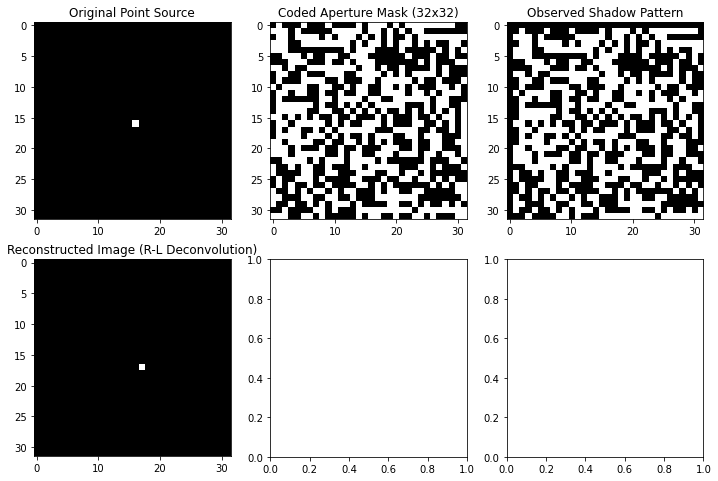

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy
from skimage.transform import resize

# Step 1: Define Original Point Source (Gaussian Blob)
def point_source(shape, center):
    """Create a true point source (single bright pixel)."""
    source = np.zeros(shape)
    source[center] = 1  # Single bright pixel
    return source

original_source = point_source((32, 32), center=(16, 16))

# Step 2: Generate Random Mask (Binary Coded Aperture) with 32x32 size
np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

# Step 3: Create Shadow Pattern with Angle Shift (Simulated Observation)
def generate_shadow(source, mask, theta_x=0, theta_y=0, h=1):
    """Generates a shadow pattern with an angular displacement."""
    shift_x = int(h * np.tan(theta_x))
    shift_y = int(h * np.tan(theta_y))
    
    shifted_mask = np.roll(mask, shift_x, axis=0)
    shifted_mask = np.roll(shifted_mask, shift_y, axis=1)
    
    shadow = convolve2d(source, shifted_mask, mode='same')
    return shadow, shifted_mask

shadow_pattern, used_mask = generate_shadow(original_source, mask, theta_x=0, theta_y=0)

# Step 4: Apply Richardson-Lucy Deconvolution
def richardson_lucy_stopping(shadow, mask, max_iter=50, tol=1e-3):
    """Perform Richardson-Lucy deconvolution and stop when correction factors reach 1."""
    estimate = np.ones_like(shadow)
    for i in range(max_iter):
        conv_result = convolve2d(estimate, mask, mode='same')
        correction = shadow / (conv_result + 1e-8)  # Avoid division by zero
        estimate *= convolve2d(correction, mask[::-1, ::-1], mode='same')
        
        if np.allclose(correction, 1, atol=tol):
            break  # Stop when correction factors stabilize
    return estimate

reconstructed_image = richardson_lucy_stopping(shadow_pattern, used_mask)

# Step 5: Generate Correctly Sized Shadow Library
shadow_lib = np.zeros((32, 32, 16, 16))  # 32x32 positions, each storing a 16x16 shadow

for x in range(32):
    for y in range(32):
        shifted_mask = np.roll(mask, x, axis=0)
        shifted_mask = np.roll(shifted_mask, y, axis=1)
        shadow_lib[x, y] = shifted_mask[:16, :16]

# Step 6: Eigenfunction-Based Restoration
def eigen_restore(shadow_lib, observed_shadow):
    """Find best coefficient match using eigen decomposition."""
    shadow_lib_reshaped = shadow_lib.reshape(32*32, -1)  # Flatten each shadow into a row
    observed_shadow_flat = observed_shadow.flatten()
    
    coeffs = np.linalg.lstsq(shadow_lib_reshaped.T, observed_shadow_flat, rcond=None)[0]
    return coeffs

coefficients = eigen_restore(shadow_lib, shadow_pattern[:16, :16])

# Step 7: Visualization
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Original Point Source
axes[0, 0].imshow(original_source, cmap='gray')
axes[0, 0].set_title("Original Point Source")

# Random Coded Aperture Mask
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Coded Aperture Mask (32x32)")

# Shadow Pattern (Observed Image)
axes[0, 2].imshow(shadow_pattern, cmap='gray')
axes[0, 2].set_title("Observed Shadow Pattern")

# Richardson-Lucy Reconstructed Image
axes[1, 0].imshow(reconstructed_image, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (R-L Deconvolution)")

# Eigenfunction Coefficients Heatmap
axes[1, 1].imshow(coefficients.reshape(32, 1), cmap='hot', aspect='auto')
axes[1, 1].set_title("Eigenfunction Coefficients")

# Difference between Original and Reconstructed
error = np.abs(original_source - reconstructed_image)
axes[1, 2].imshow(error, cmap='inferno')
axes[1, 2].set_title("Reconstruction Error")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")

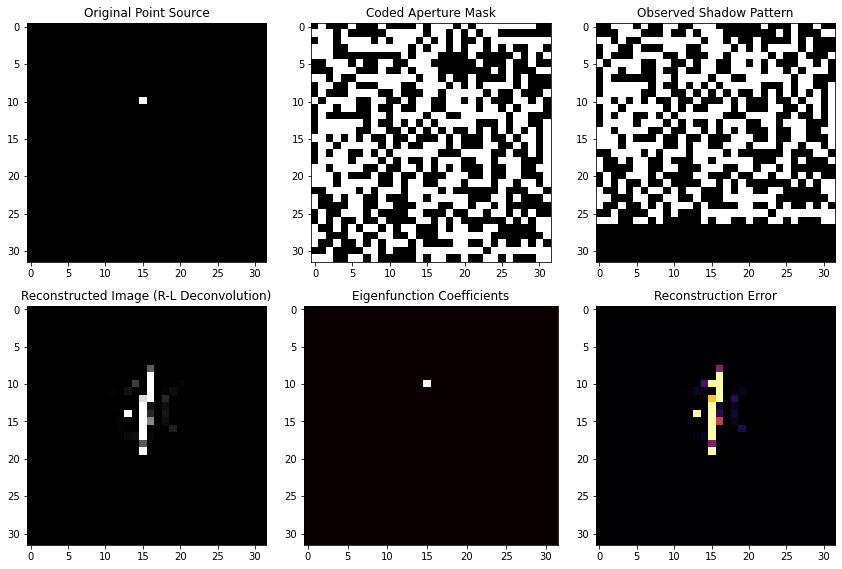

Reconstruction completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy

# Step 1: Define a Point Source
def point_source(shape, center):
    """Create a true point source (single bright pixel)."""
    source = np.zeros(shape)
    source[center] = 1  # Single bright pixel at given center
    return source

# Step 2: Generate Random Coded Aperture Mask (Binary)
np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

# Step 3: Create 1024 Shadow Patterns (One for Each Possible Source Position)
shadow_lib = np.zeros((1024, 32, 32))  # 1024 possible light source positions

index = 0
for i in range(32):  # Iterate over x-positions
    for j in range(32):  # Iterate over y-positions
        source = point_source((32, 32), center=(i, j))
        shadow_lib[index] = convolve2d(source, mask, mode='same')  # Generate shadow
        index += 1

# Step 4: Simulate an Observed Shadow Pattern
true_source_position = (10, 15)  # Example: Light source at (10,15)
true_source = point_source((32, 32), center=true_source_position)
observed_shadow = convolve2d(true_source, mask, mode='same')  # What the detector sees

# Step 5: Apply Richardson-Lucy Deconvolution
reconstructed_image = richardson_lucy(observed_shadow, mask, iterations=50)

# Step 6: Eigenfunction-Based Restoration
def eigen_restore(shadow_lib, observed_shadow):
    """Find the best coefficient match for the shadow decomposition."""
    shadow_lib_reshaped = shadow_lib.reshape(1024, -1)  # (1024, 1024)
    observed_shadow_flat = observed_shadow.flatten()  # (1024,)

    if shadow_lib_reshaped.shape[1] != observed_shadow_flat.shape[0]:
        raise ValueError(f"Dimension mismatch: Shadow lib {shadow_lib_reshaped.shape} vs Observed {observed_shadow_flat.shape}")

    coeffs = np.linalg.lstsq(shadow_lib_reshaped.T, observed_shadow_flat, rcond=None)[0]
    return coeffs

# Compute Eigenfunction Coefficients
coefficients = eigen_restore(shadow_lib, observed_shadow)

# Step 7: Visualization
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Original Point Source
axes[0, 0].imshow(true_source, cmap='gray')
axes[0, 0].set_title("Original Point Source")

# Random Coded Aperture Mask
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Coded Aperture Mask")

# Shadow Pattern (Observed Image)
axes[0, 2].imshow(observed_shadow, cmap='gray')
axes[0, 2].set_title("Observed Shadow Pattern")

# Richardson-Lucy Reconstructed Image
axes[1, 0].imshow(reconstructed_image, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (R-L Deconvolution)")

# Eigenfunction Coefficients Heatmap
axes[1, 1].imshow(coefficients.reshape(32, 32), cmap='hot', aspect='auto')
axes[1, 1].set_title("Eigenfunction Coefficients")

# Difference between Original and Reconstructed
error = np.abs(true_source - reconstructed_image)
axes[1, 2].imshow(error, cmap='inferno')
axes[1, 2].set_title("Reconstruction Error")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")

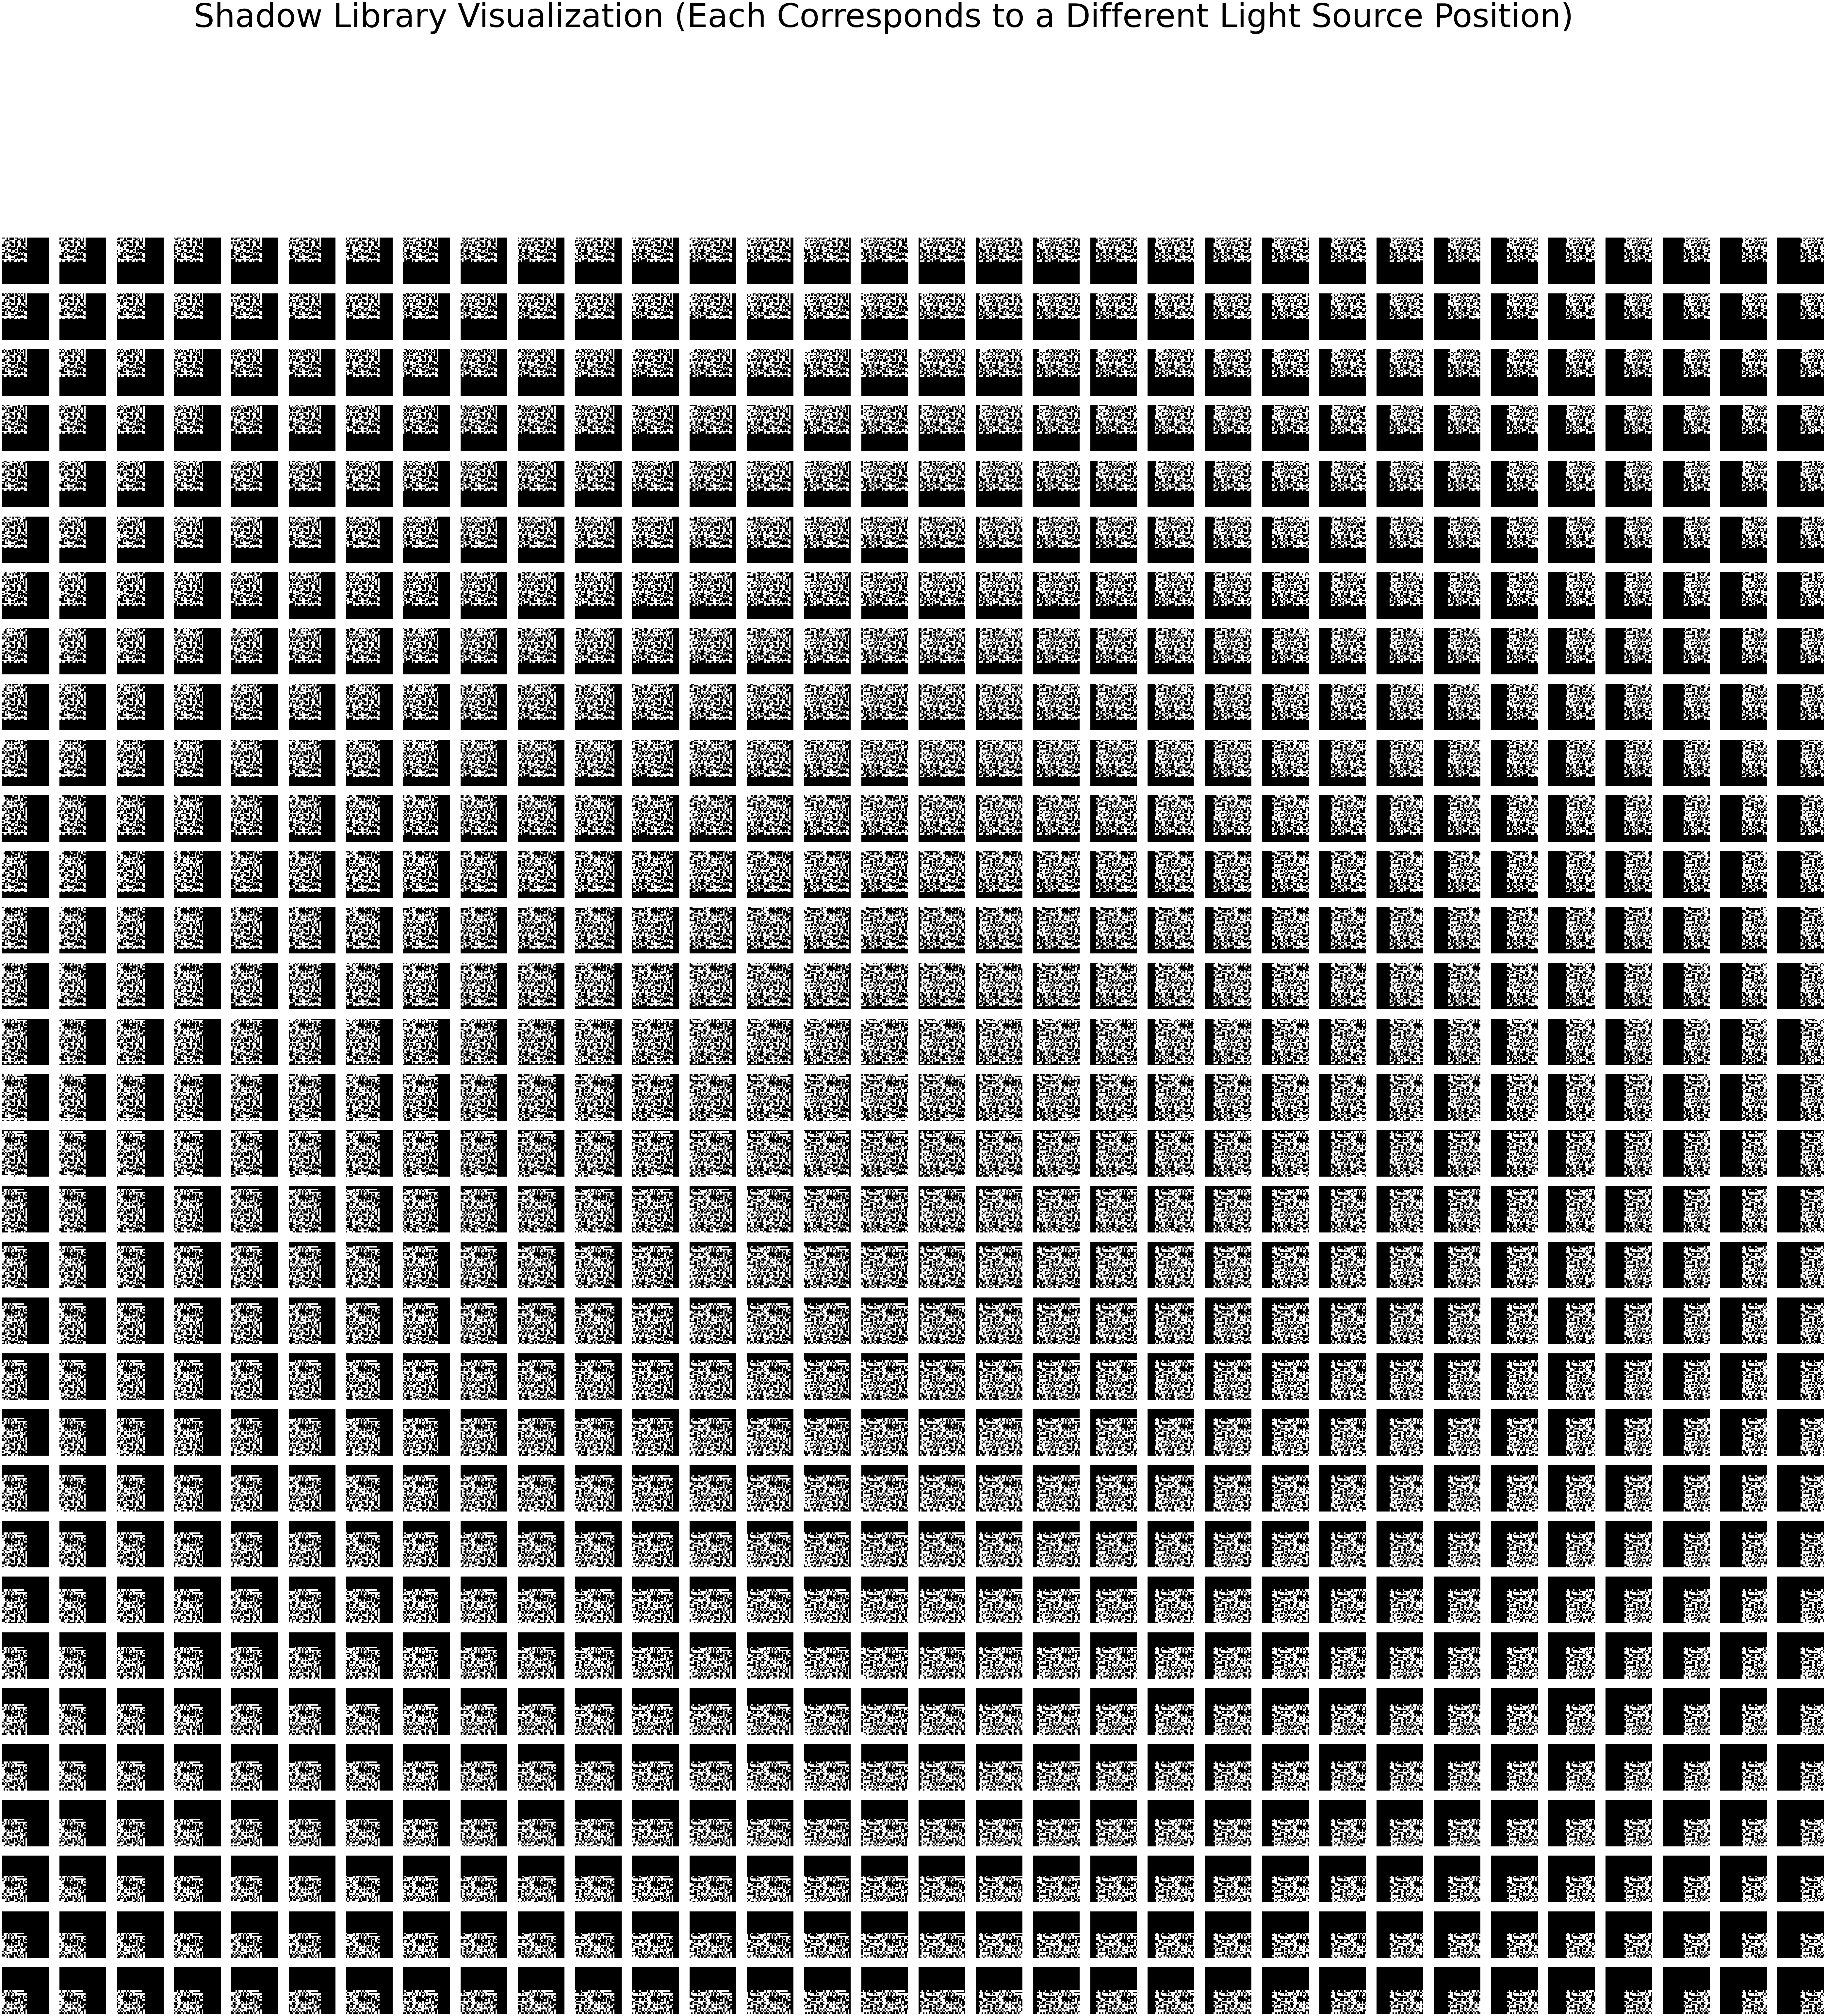

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with a 32x32 grid of subplots
fig, axes = plt.subplots(32, 32, figsize=(100, 100))  # Adjust size as needed

# Plot each shadow pattern in its corresponding grid location
index = 0
for i in range(32):
    for j in range(32):
        ax = axes[i, j]
        ax.imshow(shadow_lib[index], cmap='gray')
        ax.axis('off')  # Hide axis for clarity
        index += 1

plt.suptitle("Shadow Library Visualization (Each Corresponds to a Different Light Source Position)", fontsize=100)
plt.show()

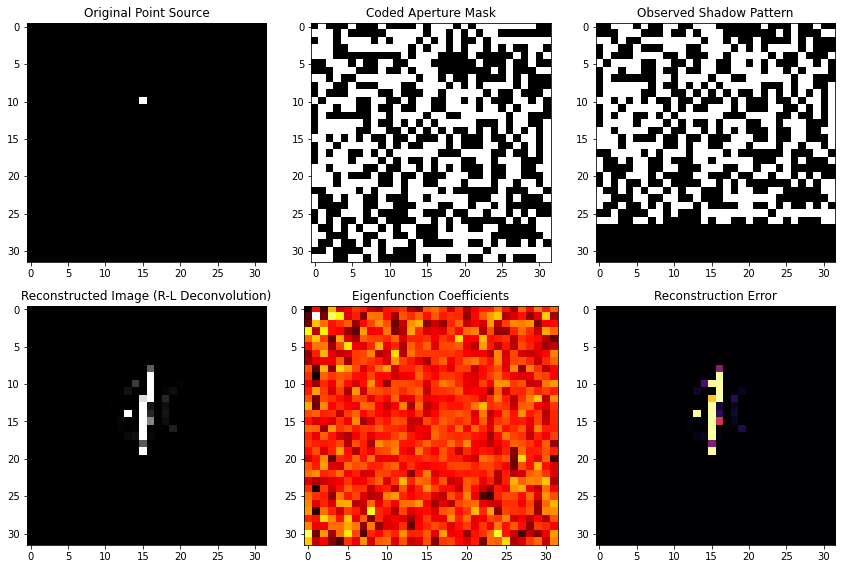

Reconstruction completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy

# Step 1: Define a Point Source
def point_source(shape, center):
    """Create a true point source (single bright pixel)."""
    source = np.zeros(shape)
    source[center] = 1  # Single bright pixel at given center
    return source

# Step 2: Generate Random Coded Aperture Mask (Binary)
np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

# Step 3: Create 1024 Shadow Patterns (One for Each Possible Source Position)
shadow_lib = np.zeros((1024, 32, 32))  # 1024 possible light source positions

index = 0
for i in range(32):  # Iterate over x-positions
    for j in range(32):  # Iterate over y-positions
        source = point_source((32, 32), center=(i, j))
        shadow = convolve2d(source, mask, mode='same')  # Use 'same' to match dimensions
        shadow = shadow / shadow.max() if shadow.max() != 0 else shadow  # Normalize safely
        shadow_lib[index] = shadow
        index += 1

# Step 4: Simulate an Observed Shadow Pattern
true_source_position = (10, 15)  # Example: Light source at (10,15)
true_source = point_source((32, 32), center=true_source_position)
observed_shadow = convolve2d(true_source, mask, mode='same')  # Simulated detector output

# Step 5: Apply Richardson-Lucy Deconvolution
padded_mask = np.pad(mask, ((0, 0), (0, 0)), mode='constant')  # Ensure correct shape
reconstructed_image = richardson_lucy(observed_shadow, padded_mask, iterations=50)

# Step 6: Eigenfunction-Based Restoration
def eigen_restore(shadow_lib, observed_shadow):
    """Find the best coefficient match for the shadow decomposition."""
    shadow_lib_reshaped = shadow_lib.reshape(1024, -1)  # Reshape to (1024, 1024)
    observed_shadow_flat = observed_shadow.flatten()  # (1024,)

    if shadow_lib_reshaped.shape[1] != observed_shadow_flat.shape[0]:
        raise ValueError(f"Dimension mismatch: Shadow lib {shadow_lib_reshaped.shape} vs Observed {observed_shadow_flat.shape}")

    coeffs = np.linalg.lstsq(shadow_lib_reshaped, observed_shadow_flat, rcond=None)[0]  # Correct orientation
    return coeffs

# Compute Eigenfunction Coefficients
coefficients = eigen_restore(shadow_lib, observed_shadow)

# Step 7: Visualization
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Original Point Source
axes[0, 0].imshow(true_source, cmap='gray')
axes[0, 0].set_title("Original Point Source")

# Random Coded Aperture Mask
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Coded Aperture Mask")

# Shadow Pattern (Observed Image)
axes[0, 2].imshow(observed_shadow, cmap='gray')
axes[0, 2].set_title("Observed Shadow Pattern")

# Richardson-Lucy Reconstructed Image
axes[1, 0].imshow(reconstructed_image, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (R-L Deconvolution)")

# Eigenfunction Coefficients Heatmap
coeff_map = coefficients.reshape(32, 32) if coefficients.size == 1024 else np.zeros((32, 32))
axes[1, 1].imshow(coeff_map, cmap='hot', aspect='auto')
axes[1, 1].set_title("Eigenfunction Coefficients")

# Difference between Original and Reconstructed
error = np.abs(true_source - reconstructed_image)
axes[1, 2].imshow(error, cmap='inferno')
axes[1, 2].set_title("Reconstruction Error")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def show_shadow(index):
    plt.figure(figsize=(5, 5))
    plt.imshow(shadow_lib[index], cmap='gray')
    plt.title(f"Shadow Pattern {index}")
    plt.axis('off')
    plt.show()

widgets.interactive(show_shadow, index=widgets.IntSlider(min=0, max=1023, step=1, value=0))

interactive(children=(IntSlider(value=0, description='index', max=1023), Output()), _dom_classes=('widget-inte…

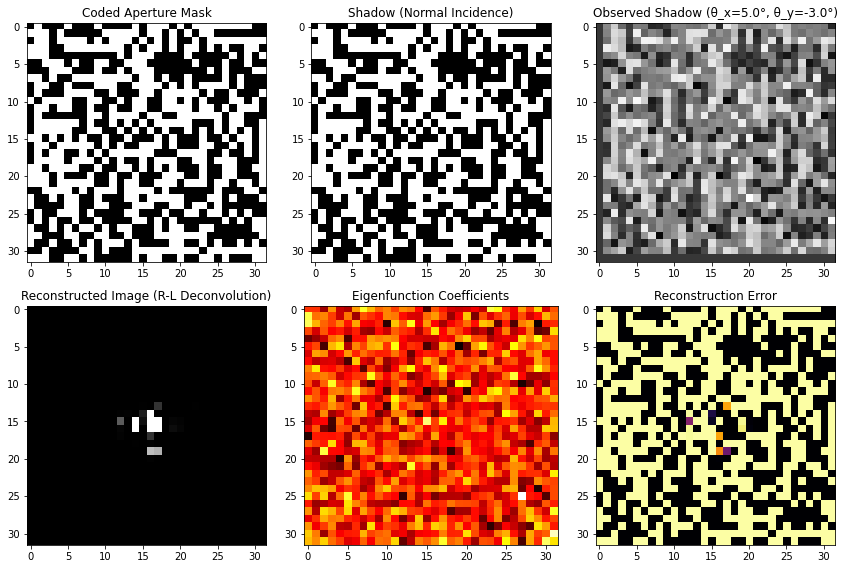

Reconstruction completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy

# Define Constants
h = 10  # Distance from source to mask in pixels
theta_min = np.arctan(1 / h)  # Smallest angle causing a 1-pixel shift

# Step 1: Define a Point Source
def point_source(shape, center):
    """Create a point source (single bright pixel)."""
    source = np.zeros(shape)
    source[center] = 1
    return source

# Step 2: Generate Random Coded Aperture Mask (Binary)
np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

# Step 3: Create Shadow Patterns for Different Angles (Instead of Grid Positions)
theta_x_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  # 32 values of θ_x
theta_y_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  # 32 values of θ_y

shadow_lib = np.zeros((32, 32, 32, 32))  # Store shadow patterns for each (theta_x, theta_y)

for i, theta_x in enumerate(theta_x_range):
    for j, theta_y in enumerate(theta_y_range):
        shift_x = h * np.tan(theta_x)  # Compute pixel shift
        shift_y = h * np.tan(theta_y)

        # Create a normal incidence shadow (mask itself)
        shadow = mask.copy().astype(float)

        # Apply affine transformation to shift shadow pattern
        shadow_shifted = affine_transform(shadow, matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

        # Normalize safely
        shadow_shifted = shadow_shifted / shadow_shifted.max() if shadow_shifted.max() != 0 else shadow_shifted

        shadow_lib[i, j] = shadow_shifted  # Store in library

# Step 4: Simulate an Observed Shadow for a Specific Angle
true_theta_x = np.deg2rad(5)  # Example: Light source at θ_x = 5 degrees
true_theta_y = np.deg2rad(-3)  # θ_y = -3 degrees
shift_x = h * np.tan(true_theta_x)
shift_y = h * np.tan(true_theta_y)

observed_shadow = affine_transform(mask.astype(float), matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

# Step 5: Apply Richardson-Lucy Deconvolution
padded_mask = np.pad(mask, ((0, 0), (0, 0)), mode='constant')  # Ensure correct shape
reconstructed_image = richardson_lucy(observed_shadow, padded_mask, iterations=50)

# Step 6: Eigenfunction-Based Restoration
def eigen_restore(shadow_lib, observed_shadow):
    """Find the best coefficient match for the shadow decomposition."""
    shadow_lib_reshaped = shadow_lib.reshape(1024, -1)  # Reshape to (1024, 1024)
    observed_shadow_flat = observed_shadow.flatten()  # (1024,)

    if shadow_lib_reshaped.shape[1] != observed_shadow_flat.shape[0]:
        raise ValueError(f"Dimension mismatch: Shadow lib {shadow_lib_reshaped.shape} vs Observed {observed_shadow_flat.shape}")

    coeffs = np.linalg.lstsq(shadow_lib_reshaped, observed_shadow_flat, rcond=None)[0]
    return coeffs

# Compute Eigenfunction Coefficients
coefficients = eigen_restore(shadow_lib.reshape(1024, 32, 32), observed_shadow)

# Step 7: Visualization
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Original Mask
axes[0, 0].imshow(mask, cmap='gray')
axes[0, 0].set_title("Coded Aperture Mask")

# Shadow Pattern at Normal Incidence
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Shadow (Normal Incidence)")

# Observed Shadow for θ_x = 5°, θ_y = -3°
axes[0, 2].imshow(observed_shadow, cmap='gray')
axes[0, 2].set_title(f"Observed Shadow (θ_x={np.rad2deg(true_theta_x):.1f}°, θ_y={np.rad2deg(true_theta_y):.1f}°)")

# Richardson-Lucy Reconstructed Image
axes[1, 0].imshow(reconstructed_image, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (R-L Deconvolution)")

# Eigenfunction Coefficients Heatmap
coeff_map = coefficients.reshape(32, 32) if coefficients.size == 1024 else np.zeros((32, 32))
axes[1, 1].imshow(coeff_map, cmap='hot', aspect='auto')
axes[1, 1].set_title("Eigenfunction Coefficients")

# Difference between Original and Reconstructed
error = np.abs(mask - reconstructed_image)
axes[1, 2].imshow(error, cmap='inferno')
axes[1, 2].set_title("Reconstruction Error")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")

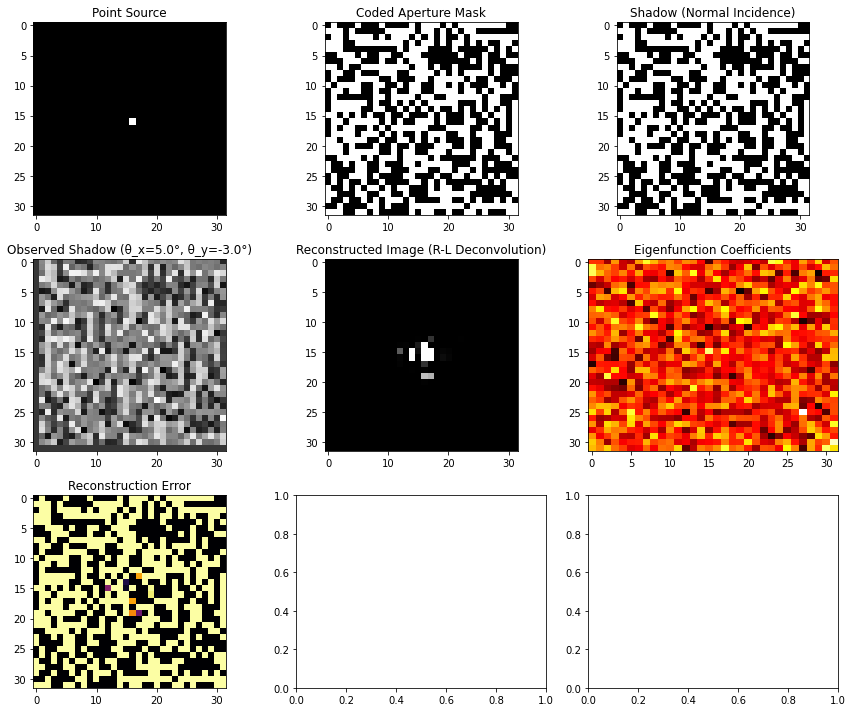

Reconstruction completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy

# Define Constants
h = 10  # Distance from source to mask in pixels
theta_min = np.arctan(1 / h)  # Smallest angle causing a 1-pixel shift

# Step 1: Define a Point Source
def point_source(shape, center):
    """Create a point source (single bright pixel)."""
    source = np.zeros(shape)
    source[center] = 1
    return source

# Step 2: Generate Random Coded Aperture Mask (Binary)
np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

# Step 3: Create Shadow Patterns for Different Angles (Instead of Grid Positions)
theta_x_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  # 32 values of θ_x
theta_y_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  # 32 values of θ_y

shadow_lib = np.zeros((32, 32, 32, 32))  # Store shadow patterns for each (theta_x, theta_y)

for i, theta_x in enumerate(theta_x_range):
    for j, theta_y in enumerate(theta_y_range):
        shift_x = h * np.tan(theta_x)  # Compute pixel shift
        shift_y = h * np.tan(theta_y)

        # Create a normal incidence shadow (mask itself)
        shadow = mask.copy().astype(float)

        # Apply affine transformation to shift shadow pattern
        shadow_shifted = affine_transform(shadow, matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

        # Normalize safely
        shadow_shifted = shadow_shifted / shadow_shifted.max() if shadow_shifted.max() != 0 else shadow_shifted

        shadow_lib[i, j] = shadow_shifted  # Store in library

# Step 4: Simulate an Observed Shadow for a Specific Angle
true_theta_x = np.deg2rad(5)  # Example: Light source at θ_x = 5 degrees
true_theta_y = np.deg2rad(-3)  # θ_y = -3 degrees
shift_x = h * np.tan(true_theta_x)
shift_y = h * np.tan(true_theta_y)

observed_shadow = affine_transform(mask.astype(float), matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

# Step 5: Apply Richardson-Lucy Deconvolution
padded_mask = np.pad(mask, ((0, 0), (0, 0)), mode='constant')  # Ensure correct shape
reconstructed_image = richardson_lucy(observed_shadow, padded_mask, iterations=50)

# Step 6: Eigenfunction-Based Restoration
def eigen_restore(shadow_lib, observed_shadow):
    """Find the best coefficient match for the shadow decomposition."""
    shadow_lib_reshaped = shadow_lib.reshape(1024, -1)  # Reshape to (1024, 1024)
    observed_shadow_flat = observed_shadow.flatten()  # (1024,)

    if shadow_lib_reshaped.shape[1] != observed_shadow_flat.shape[0]:
        raise ValueError(f"Dimension mismatch: Shadow lib {shadow_lib_reshaped.shape} vs Observed {observed_shadow_flat.shape}")

    coeffs = np.linalg.lstsq(shadow_lib_reshaped, observed_shadow_flat, rcond=None)[0]
    return coeffs

# Compute Eigenfunction Coefficients
coefficients = eigen_restore(shadow_lib.reshape(1024, 32, 32), observed_shadow)

# Step 7: Visualization
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

# Original Point Source
source = point_source((32, 32), (16, 16))
axes[0, 0].imshow(source, cmap='gray')
axes[0, 0].set_title("Point Source")

# Original Mask
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Coded Aperture Mask")

# Shadow Pattern at Normal Incidence
axes[0, 2].imshow(mask, cmap='gray')
axes[0, 2].set_title("Shadow (Normal Incidence)")

# Observed Shadow for θ_x = 5°, θ_y = -3°
axes[1, 0].imshow(observed_shadow, cmap='gray')
axes[1, 0].set_title(f"Observed Shadow (θ_x={np.rad2deg(true_theta_x):.1f}°, θ_y={np.rad2deg(true_theta_y):.1f}°)")

# Richardson-Lucy Reconstructed Image
axes[1, 1].imshow(reconstructed_image, cmap='gray')
axes[1, 1].set_title("Reconstructed Image (R-L Deconvolution)")

# Eigenfunction Coefficients Heatmap
coeff_map = coefficients.reshape(32, 32) if coefficients.size == 1024 else np.zeros((32, 32))
axes[1, 2].imshow(coeff_map, cmap='hot', aspect='auto')
axes[1, 2].set_title("Eigenfunction Coefficients")

# Difference between Original and Reconstructed
error = np.abs(mask - reconstructed_image)
axes[2, 0].imshow(error, cmap='inferno')
axes[2, 0].set_title("Reconstruction Error")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")

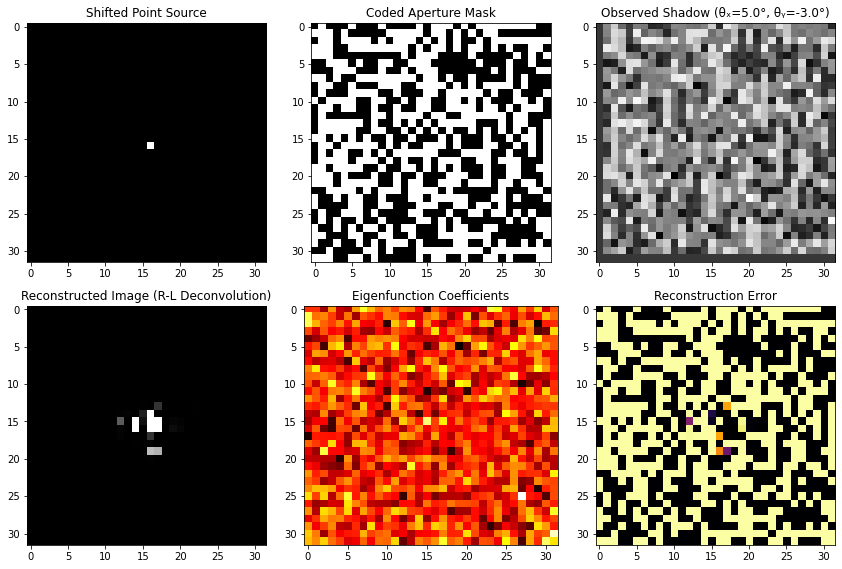

Reconstruction completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy

# Define Constants
h = 10  # Distance from source to mask in pixels
theta_min = np.arctan(1 / h)  # Smallest angle causing a 1-pixel shift

# Step 1: Generate Random Coded Aperture Mask (Binary)
np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

# Step 2: Create Shadow Patterns for Different Angles
theta_x_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  
theta_y_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  

shadow_lib = np.zeros((32, 32, 32, 32))  

for i, theta_x in enumerate(theta_x_range):
    for j, theta_y in enumerate(theta_y_range):
        shift_x = h * np.tan(theta_x)  
        shift_y = h * np.tan(theta_y)

        shadow = mask.copy().astype(float)
        shadow_shifted = affine_transform(shadow, matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

        shadow_shifted = shadow_shifted / shadow_shifted.max() if shadow_shifted.max() != 0 else shadow_shifted
        shadow_lib[i, j] = shadow_shifted  

# Step 3: Simulate an Observed Shadow for θₓ = 5.0°, θᵧ = -3.0°
true_theta_x = np.deg2rad(5)  
true_theta_y = np.deg2rad(-3)  
shift_x = h * np.tan(true_theta_x)
shift_y = h * np.tan(true_theta_y)

# Shifted Point Source at (θₓ, θᵧ)
shifted_source = np.zeros((32, 32))
center_x, center_y = 16 + int(shift_x), 16 + int(shift_y)  
if 0 <= center_x < 32 and 0 <= center_y < 32:
    shifted_source[center_y, center_x] = 1  

observed_shadow = affine_transform(mask.astype(float), matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

# Step 4: Apply Richardson-Lucy Deconvolution
reconstructed_image = richardson_lucy(observed_shadow, mask, iterations=50)

# Step 5: Eigenfunction-Based Restoration
def eigen_restore(shadow_lib, observed_shadow):
    shadow_lib_reshaped = shadow_lib.reshape(1024, -1)  
    observed_shadow_flat = observed_shadow.flatten()  

    coeffs = np.linalg.lstsq(shadow_lib_reshaped, observed_shadow_flat, rcond=None)[0]
    return coeffs

coefficients = eigen_restore(shadow_lib.reshape(1024, 32, 32), observed_shadow)

# Step 6: Visualization
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Shifted Point Source (θₓ = 5.0°, θᵧ = -3.0°)
axes[0, 0].imshow(shifted_source, cmap='gray')
axes[0, 0].set_title("Shifted Point Source")

# Coded Aperture Mask
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Coded Aperture Mask")

# Observed Shadow (θₓ = 5.0°, θᵧ = -3.0°)
axes[0, 2].imshow(observed_shadow, cmap='gray')
axes[0, 2].set_title(f"Observed Shadow (θₓ={np.rad2deg(true_theta_x):.1f}°, θᵧ={np.rad2deg(true_theta_y):.1f}°)")

# Richardson-Lucy Reconstructed Image
axes[1, 0].imshow(reconstructed_image, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (R-L Deconvolution)")

# Eigenfunction Coefficients Heatmap
coeff_map = coefficients.reshape(32, 32) if coefficients.size == 1024 else np.zeros((32, 32))
axes[1, 1].imshow(coeff_map, cmap='hot', aspect='auto')
axes[1, 1].set_title("Eigenfunction Coefficients")

# Reconstruction Error
error = np.abs(mask - reconstructed_image)
axes[1, 2].imshow(error, cmap='inferno')
axes[1, 2].set_title("Reconstruction Error")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")

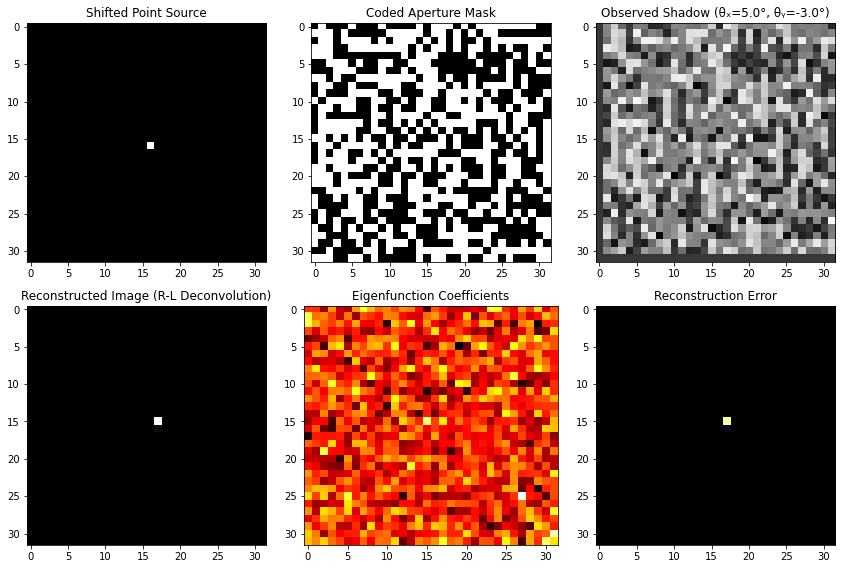

Reconstruction completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from scipy.signal import convolve2d

# Define Constants
h = 10  # Distance from source to mask in pixels
theta_min = np.arctan(1 / h)  # Smallest angle causing a 1-pixel shift

# Step 1: Generate Random Coded Aperture Mask (Binary)
np.random.seed(42)
mask = np.random.choice([0, 1], size=(32, 32))

# Step 2: Create Shadow Patterns for Different Angles
theta_x_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  
theta_y_range = np.linspace(-theta_min * 16, theta_min * 16, 32)  

shadow_lib = np.zeros((32, 32, 32, 32))  

for i, theta_x in enumerate(theta_x_range):
    for j, theta_y in enumerate(theta_y_range):
        shift_x = h * np.tan(theta_x)  
        shift_y = h * np.tan(theta_y)

        shadow = mask.copy().astype(float)
        shadow_shifted = affine_transform(shadow, matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

        shadow_shifted = shadow_shifted / shadow_shifted.max() if shadow_shifted.max() != 0 else shadow_shifted
        shadow_lib[i, j] = shadow_shifted  

# Step 3: Simulate an Observed Shadow for θₓ = 5.0°, θᵧ = -3.0°
true_theta_x = np.deg2rad(5)  
true_theta_y = np.deg2rad(-3)  
shift_x = h * np.tan(true_theta_x)
shift_y = h * np.tan(true_theta_y)

# Shifted Point Source at (θₓ, θᵧ)
shifted_source = np.zeros((32, 32))
center_x, center_y = 16 + int(shift_x), 16 + int(shift_y)  
if 0 <= center_x < 32 and 0 <= center_y < 32:
    shifted_source[center_y, center_x] = 1  

observed_shadow = affine_transform(mask.astype(float), matrix=np.eye(2), offset=(-shift_y, -shift_x), mode='constant')

# Step 4: Implement Custom Richardson-Lucy Deconvolution
def richardson_lucy_auto_displacement(observed, psf, epsilon=1e-5, max_iter=50):
    F = np.full_like(observed, np.mean(observed))  # Start with mean guess
    for _ in range(max_iter):
        G = convolve2d(F, psf, mode='same', boundary='wrap')
        C = observed / (G + epsilon)
        correction = convolve2d(C, np.flip(psf), mode='same', boundary='wrap')
        F = F * correction
    return F

# Apply RL Deconvolution
reconstructed_image = richardson_lucy_auto_displacement(observed_shadow, mask, max_iter=50)

# Step 5: Eigenfunction-Based Restoration
def eigen_restore(shadow_lib, observed_shadow):
    shadow_lib_reshaped = shadow_lib.reshape(1024, -1)  
    observed_shadow_flat = observed_shadow.flatten()  

    coeffs = np.linalg.lstsq(shadow_lib_reshaped, observed_shadow_flat, rcond=None)[0]
    return coeffs

coefficients = eigen_restore(shadow_lib.reshape(1024, 32, 32), observed_shadow)

# Step 6: Visualization
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Shifted Point Source (θₓ = 5.0°, θᵧ = -3.0°)
axes[0, 0].imshow(shifted_source, cmap='gray')
axes[0, 0].set_title("Shifted Point Source")

# Coded Aperture Mask
axes[0, 1].imshow(mask, cmap='gray')
axes[0, 1].set_title("Coded Aperture Mask")

# Observed Shadow (θₓ = 5.0°, θᵧ = -3.0°)
axes[0, 2].imshow(observed_shadow, cmap='gray')
axes[0, 2].set_title(f"Observed Shadow (θₓ={np.rad2deg(true_theta_x):.1f}°, θᵧ={np.rad2deg(true_theta_y):.1f}°)")

# Richardson-Lucy Reconstructed Image
axes[1, 0].imshow(reconstructed_image, cmap='gray')
axes[1, 0].set_title("Reconstructed Image (R-L Deconvolution)")

# Eigenfunction Coefficients Heatmap
coeff_map = coefficients.reshape(32, 32) if coefficients.size == 1024 else np.zeros((32, 32))
axes[1, 1].imshow(coeff_map, cmap='hot', aspect='auto')
axes[1, 1].set_title("Eigenfunction Coefficients")

# Reconstruction Error
error = np.abs(mask - reconstructed_image)
axes[1, 2].imshow(error, cmap='inferno')
axes[1, 2].set_title("Reconstruction Error")

plt.tight_layout()
plt.show()

print("Reconstruction completed.")

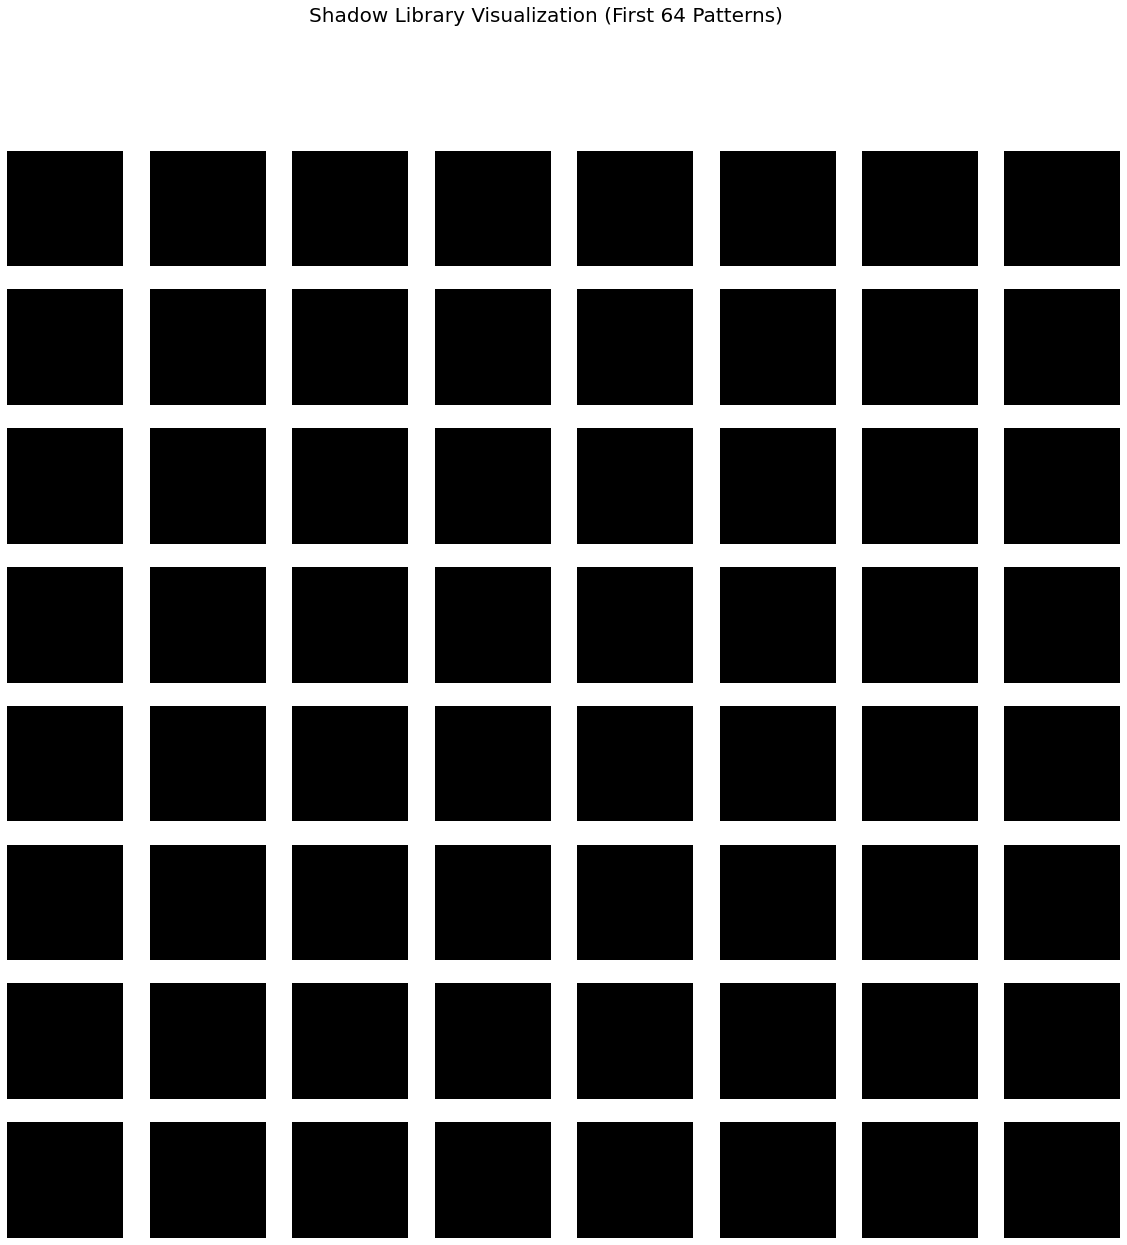

In [20]:
import matplotlib.pyplot as plt

def plot_shadow_library(shadow_lib, grid_size=(8, 8)):
    """
    Plots a batch of shadow patterns from the shadow library.
    
    Parameters:
    shadow_lib : numpy array
        The 32x32x32x32 shadow library.
    grid_size : tuple
        Number of rows and columns in the plot grid.
    """
    fig, axes = plt.subplots(*grid_size, figsize=(20, 20))  # Adjust figure size for visibility
    index = 0
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            if index >= 64:  # Display only the first 64 shadows
                break
            ax = axes[i, j]
            ax.imshow(shadow_lib[index // 32, index % 32], cmap='gray')
            ax.axis('off')
            index += 1
    plt.suptitle(f"Shadow Library Visualization (First {grid_size[0] * grid_size[1]} Patterns)", fontsize=20)
    plt.show()

# Call the function to visualize
plot_shadow_library(shadow_lib, grid_size=(8, 8))